In [2]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
(11162, 17)
age           int64
job          object
marital      object
education    object
default

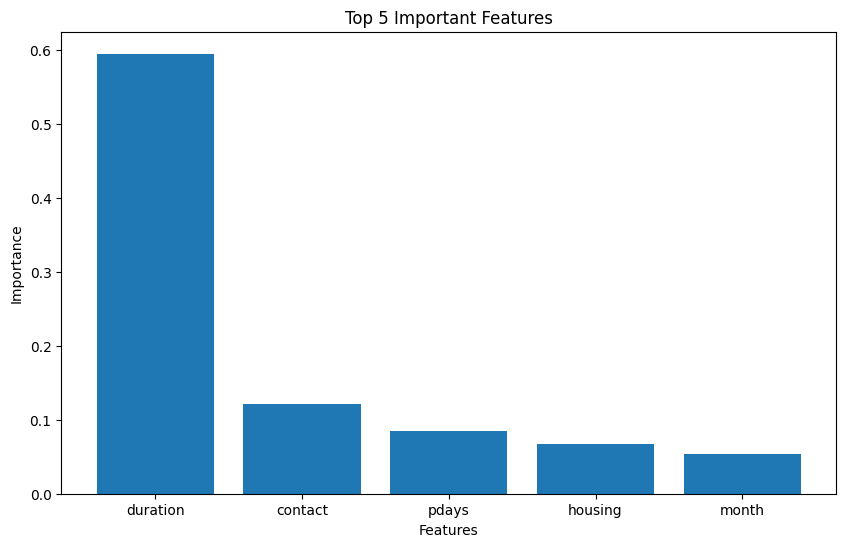

Customers with stable jobs and higher balances
are more likely to say yes.
Banks should target high-conversion customers
using personalized marketing campaigns.


In [3]:
# ============================================================
# Decision Tree Assignment Solution
# Dataset: bank.csv
# PwSkills
# ============================================================

# ============================================================
# Q6. Data Understanding
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("bank.csv")

print(df.head())

print(df.shape)

print(df.dtypes)

print(df.columns)

# ============================================================
# Q7. Data Cleaning
# ============================================================

print(df.isnull().sum())

# Handle Missing Values

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check duplicates

print("Duplicates:", df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

# ============================================================
# Q8. Data Preprocessing
# ============================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ============================================================
# Q9. Feature Selection & Splitting
# ============================================================

X = df.drop('deposit', axis=1)

y = df['deposit']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# Q10. Model Building
# ============================================================

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ============================================================
# Q11. Model Evaluation
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

print(cm)

print(classification_report(y_test, y_pred))

# ============================================================
# Q12. Overfitting Check
# ============================================================

train_accuracy = model.score(X_train, y_train)

test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)

print("Testing Accuracy:", test_accuracy)

# ============================================================
# Q13. Pruning Experiment
# ============================================================

pruned_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

pruned_pred = pruned_model.predict(X_test)

pruned_accuracy = accuracy_score(y_test, pruned_pred)

print("Pruned Accuracy:", pruned_accuracy)

# ============================================================
# Q14. Feature Importance
# ============================================================

import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head())

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'][:5],
    feature_importance['Importance'][:5]
)

plt.title("Top 5 Important Features")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# ============================================================
# Q15. Business Insights
# ============================================================

print("Customers with stable jobs and higher balances")
print("are more likely to say yes.")

print("Banks should target high-conversion customers")
print("using personalized marketing campaigns.")